In [1]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
import torch
import torch.nn as nn
import torch.nn.functional as F
import sys
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EvokedParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [2]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [3]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Evoked feature extraction params ([-2, 0] s)
params = EvokedParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
    spatial_colors=True,
    average_line=True,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


### Load

In [4]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [5]:
evk_list, ok_subjects = [], []
task_name = 'contrastChangeDetection'

for subj in selected_subjects:
    subj_tasks = subject_model.list_tasks(subj)
    runs = [r for (t, r) in subj_tasks if t == task_name] or [None]

    evks = []
    for run in runs:
        dto = TaskDTO(subject=subj, task=task_name, run=run)
        evk = controller.get_evoked(dto, params)
        if evk is None:
            continue
        evks.append(prepare_channels(evk, params))

    if not evks:
        continue

    evk_avg = evks[0] if len(evks) == 1 else grand_average(evks)
    evk_list.append(evk_avg)
    ok_subjects.append(subj)

df_meta = subject_model.get_subjects_metadata(ok_subjects, columns=['ccd_accuracy','ccd_response_time'])
df_meta = df_meta.set_index('participant_id').loc[ok_subjects]
y_df = df_meta[['ccd_accuracy','ccd_response_time']].copy()
y = y_df.astype(float).values

## model

### EEGNetMultiReg Configuration (Compact NN Version)

Input:
- Up to 500 subjects
- 2-second ITI CCD evoked responses
- Channels: 69–76, 81–83, 88, 89

Data split:
- Train/Validation/Test split: 70% / 15% / 15%

Target modeling strategy:
- A single multi-output neural network model (`EEGNetMultiReg`) is trained to jointly predict ACC and RT.

Model pipeline:
- Build fixed-shape evoked tensors across subjects
- **Train-only standardization** for EEG inputs (channel-time wise), then clip extreme z-scores
- Compact temporal CNN (`Conv1d + BatchNorm + ELU + Dropout`) with global temporal pooling
- Final regression head: `Linear(2)` for simultaneous ACC and RT prediction

Why compact:
- Lower model capacity is better matched to small sample sizes.
- Smaller kernels (7/5/3) preserve short-window temporal detail better than large kernels.
- Strong regularization (dropout, AdamW, gradient clipping, LR scheduler, early stopping) improves stability.

Training objective and evaluation:
- Training loss: Huber loss (δ=1.0) on standardized targets
- Test metrics: MAE, Pearson correlation, and R² for ACC and RT
- Baseline comparison: hold-out MAE against train-mean predictor

In [ ]:
class EEGNetMultiReg(nn.Module):
    """Build a compact temporal CNN for multi-target EEG regression."""

    DISPLAY_NAME = "Compact EEGReg (multi-regression)"
    DESCRIPTION = (
        "Compact 1D temporal CNN with global pooling and a small regression head "
        "for low-sample multi-target prediction."
    )

    def __init__(self, n_outputs: int = 1, dropout: float = 0.35):
        """Initialize a low-capacity network tuned for small datasets."""
        super().__init__()
        self.n_outputs = int(n_outputs)

        # Input shape: (batch, channels, time)
        self.temporal_1 = nn.LazyConv1d(32, kernel_size=7, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(32)
        self.temporal_2 = nn.Conv1d(32, 32, kernel_size=5, padding=2, bias=False)
        self.bn2 = nn.BatchNorm1d(32)
        self.temporal_3 = nn.Conv1d(32, 16, kernel_size=3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm1d(16)

        self.dropout = nn.Dropout(dropout)
        self.fc_reg = nn.Linear(16, self.n_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return continuous predictions with shape (batch_size, n_outputs)."""
        if x.ndim != 3:
            raise ValueError(f'Expected input with 3 dims (batch, channels, time), got {tuple(x.shape)}')

        x = F.elu(self.bn1(self.temporal_1(x)))
        x = self.dropout(x)
        x = F.elu(self.bn2(self.temporal_2(x)))
        x = self.dropout(x)
        x = F.elu(self.bn3(self.temporal_3(x)))

        # Global temporal pooling
        x = x.mean(dim=-1)
        return self.fc_reg(x)

## Train
Build a fixed-shape tensor dataset from per-subject evoked averages, then train EEGNet for multi-target regression (ACC, RT).

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def evoked_to_fixed_array(evk, ref_ch_names, ref_times):
    """Convert an Evoked to a fixed (n_ch, n_times) float32 array."""
    ref_ch_to_idx = {ch: i for i, ch in enumerate(ref_ch_names)}
    out = np.zeros((len(ref_ch_names), len(ref_times)), dtype=np.float32)

    src_times = evk.times.astype(float)
    src_data = evk.data.astype(np.float32, copy=False)
    if src_data.shape[1] != len(ref_times) or not np.allclose(src_times, ref_times, atol=1e-9, rtol=0.0):
        interp = np.empty((src_data.shape[0], len(ref_times)), dtype=np.float32)
        for ci in range(src_data.shape[0]):
            interp[ci] = np.interp(ref_times, src_times, src_data[ci]).astype(np.float32)
        src_data = interp

    for src_i, ch in enumerate(evk.ch_names):
        dst_i = ref_ch_to_idx.get(ch)
        if dst_i is None:
            continue
        out[dst_i] = src_data[src_i]

    return out

# Build X_raw (subjects x channels x time) with a stable channel/time layout
if not evk_list:
    raise RuntimeError('evk_list is empty. Run the Load cell first.')
ref_ch_names = list(evk_list[0].ch_names)
ref_times = evk_list[0].times.astype(float)

X_list = []
keep_idx = []
for i, evk in enumerate(evk_list):
    arr = evoked_to_fixed_array(evk, ref_ch_names=ref_ch_names, ref_times=ref_times)
    if not np.isfinite(arr).all():
        continue
    X_list.append(arr)
    keep_idx.append(i)

X_raw = np.stack(X_list, axis=0).astype(np.float32)
y = np.asarray(y, dtype=np.float32)[keep_idx]
ok_subjects = [ok_subjects[i] for i in keep_idx]

print('X_raw:', X_raw.shape, 'y:', y.shape, 'subjects:', len(ok_subjects))

X: (500, 13, 201) y: (500, 2) subjects: 500


In [ ]:
# Train/val/test split
X_train_raw, X_tmp_raw, y_train, y_tmp = train_test_split(
    X_raw, y, test_size=0.3, random_state=42
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_tmp_raw, y_tmp, test_size=0.5, random_state=42
)

# Standardize EEG inputs using TRAIN stats only (channel-time wise)
x_mean = X_train_raw.mean(axis=0, keepdims=True)
x_std = X_train_raw.std(axis=0, keepdims=True) + 1e-6

X_train = (X_train_raw - x_mean) / x_std
X_val = (X_val_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

# Clip extreme z-scores to reduce outlier impact
X_train = np.clip(X_train, -5.0, 5.0)
X_val = np.clip(X_val, -5.0, 5.0)
X_test = np.clip(X_test, -5.0, 5.0)

# Standardize targets using train stats only
y_mean = y_train.mean(axis=0, keepdims=True)
y_std = y_train.std(axis=0, keepdims=True) + 1e-6
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std
y_test_s = (y_test - y_mean) / y_std

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (350, 13, 201) (350, 2)
Val  : (75, 13, 201) (75, 2)
Test : (75, 13, 201) (75, 2)


Device: cuda


/root/miniconda3/envs/py312_env/lib/python3.12/site-packages/torch/cuda/__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5080 with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_89 sm_90 compute_90.
If you want to use the NVIDIA GeForce RTX 5080 GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


Epoch 001 | train 0.5766 | val 0.4455 | best 0.4455
Epoch 010 | train 0.1946 | val 0.4014 | best 0.4014
Epoch 020 | train 0.1319 | val 0.4525 | best 0.3788
Epoch 030 | train 0.0950 | val 0.4240 | best 0.3744
Epoch 040 | train 0.0856 | val 0.4793 | best 0.3744
Early stop at epoch 45


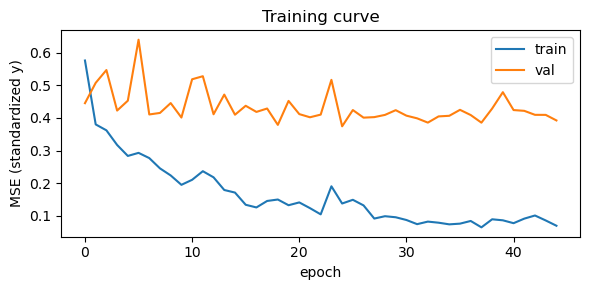

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

# Repro + device
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train_s),
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val_s),
)
test_ds = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test_s),
)

batch_size = 16
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, drop_last=False)

model = EEGNetMultiReg(n_outputs=2, dropout=0.35).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.HuberLoss(delta=1.0)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-5
)

def run_epoch(loader, train=False):
    """Run one epoch and return mean loss."""
    model.train(train)
    total = 0.0
    n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        if train:
            optimizer.zero_grad(set_to_none=True)

        pred = model(xb)
        loss = criterion(pred, yb)

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total += float(loss.item()) * xb.shape[0]
        n += xb.shape[0]
    return total / max(1, n)

# Training loop with early stopping + LR scheduling
best_val = float('inf')
best_state = None
patience = 30
bad = 0
max_epochs = 300
history = []

for epoch in range(1, max_epochs + 1):
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader, train=False)
    scheduler.step(va)
    history.append((tr, va))

    if va < best_val - 1e-5:
        best_val = va
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:03d} | lr {current_lr:.2e} | train {tr:.4f} | val {va:.4f} | best {best_val:.4f}')

    if bad >= patience:
        print('Early stop at epoch', epoch)
        break

if best_state is not None:
    model.load_state_dict(best_state)

# Plot loss curves
tr_hist = [h[0] for h in history]
va_hist = [h[1] for h in history]
plt.figure(figsize=(6, 3))
plt.plot(tr_hist, label='train')
plt.plot(va_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('Huber loss (standardized y)')
plt.title('Training curve')
plt.legend()
plt.tight_layout()
plt.show()

Test ACC: corr= 0.10784044675731988 MAE= 19.428768157958984
Test RT : corr= 0.06672797069645478 MAE= 0.21019363403320312


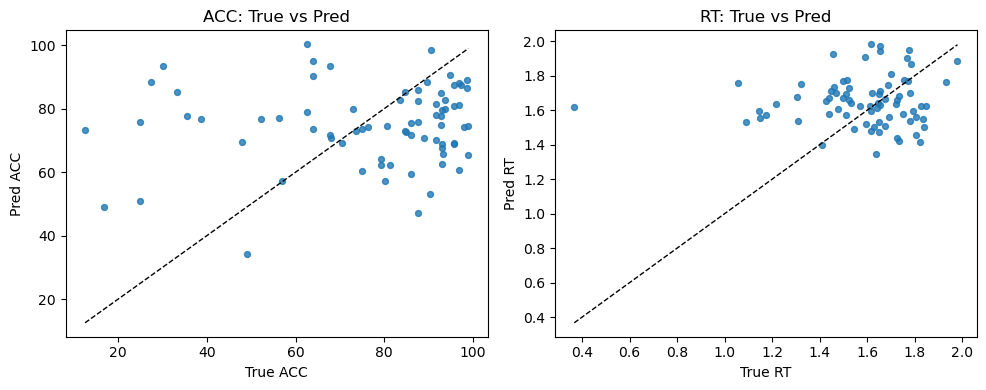

In [11]:
# Evaluate + plot True vs Pred on test
model.eval()
pred_list = []
true_list = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        pred_list.append(pred)
        true_list.append(yb.cpu().numpy())
y_pred_s = np.vstack(pred_list)
y_true_s = np.vstack(true_list)

# Unstandardize
y_pred = y_pred_s * y_std + y_mean
y_true = y_true_s * y_std + y_mean

def corr(a, b):
    if len(a) < 2:
        return float('nan')
    return float(np.corrcoef(a, b)[0, 1])

mae_acc = float(np.mean(np.abs(y_true[:, 0] - y_pred[:, 0])))
mae_rt = float(np.mean(np.abs(y_true[:, 1] - y_pred[:, 1])))
corr_acc = corr(y_true[:, 0], y_pred[:, 0])
corr_rt = corr(y_true[:, 1], y_pred[:, 1])
print('Test ACC: corr=', corr_acc, 'MAE=', mae_acc)
print('Test RT : corr=', corr_rt,  'MAE=', mae_rt)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_true[:, 0], y_pred[:, 0], s=18, alpha=0.8)
lo, hi = np.min(y_true[:, 0]), np.max(y_true[:, 0])
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('True ACC')
axes[0].set_ylabel('Pred ACC')
axes[0].set_title('ACC: True vs Pred')

axes[1].scatter(y_true[:, 1], y_pred[:, 1], s=18, alpha=0.8)
lo, hi = np.min(y_true[:, 1]), np.max(y_true[:, 1])
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[1].set_xlabel('True RT')
axes[1].set_ylabel('Pred RT')
axes[1].set_title('RT: True vs Pred')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import r2_score

# R2
r2_acc = r2_score(y_true[:, 0], y_pred[:, 0])
r2_rt = r2_score(y_true[:, 1], y_pred[:, 1])

# Baseline MAE using TRAIN mean predictor (proper hold-out baseline)
baseline_pred_acc = np.full_like(y_true[:, 0], fill_value=float(y_mean[0, 0]))
baseline_pred_rt = np.full_like(y_true[:, 1], fill_value=float(y_mean[0, 1]))
baseline_acc = np.mean(np.abs(y_true[:, 0] - baseline_pred_acc))
baseline_rt = np.mean(np.abs(y_true[:, 1] - baseline_pred_rt))

improve_acc = baseline_acc - mae_acc
improve_rt = baseline_rt - mae_rt

print("ACC -> MAE:", mae_acc, "Baseline:", baseline_acc, "ΔMAE:", improve_acc, "R2:", r2_acc, "Corr:", corr_acc)
print("RT  -> MAE:", mae_rt,  "Baseline:", baseline_rt,  "ΔMAE:", improve_rt,  "R2:", r2_rt,  "Corr:", corr_rt)

ACC -> MAE: 19.428768157958984 Baseline: 17.965117 R2: -0.18726015090942383 Corr: 0.10784044675731988
RT  -> MAE: 0.21019363403320312 Baseline: 0.1716642 R2: -0.35677289962768555 Corr: 0.06672797069645478
